# Notebook 3 — Full Pipeline: CLIP + BLIP-2 + Claude Report
Runs both models on an X-ray and synthesizes a structured radiology-style report
using the Claude API.

In [1]:
import sys, os
sys.path.insert(0, '..')

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import csv

# Load .env file if present (safe: never committed, in .gitignore)
env_file = Path('../.env')
if env_file.exists():
    for line in env_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            k, v = line.split('=', 1)
            os.environ.setdefault(k.strip(), v.strip())

from pipeline.report_generator import ReportGenerator

api_key = os.environ.get('ANTHROPIC_API_KEY', '')
print(f'ANTHROPIC_API_KEY set: {bool(api_key)}')

ANTHROPIC_API_KEY set: True


## 1. Load the full pipeline

In [2]:
generator = ReportGenerator()
print('Pipeline ready (BiomedCLIP + BLIP-2 + Claude)')

Loading BiomedCLIP on cpu...


BiomedCLIP loaded.


Loading BLIP VQA on cpu...


The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLIP VQA loaded.
Pipeline ready (BiomedCLIP + BLIP-2 + Claude)


## 2. Run on all eval images

In [3]:
eval_dir = Path('../data/eval')
with open(eval_dir / 'labels.csv', encoding='utf-8') as f:
    samples = list(csv.DictReader(f))

print(f'Will analyze {len(samples)} images')

Will analyze 7 images


In [4]:
all_results = []

for sample in samples:
    img_path = eval_dir / sample['filename']
    image = Image.open(img_path).convert('RGB')
    
    print(f"\n{'='*65}")
    print(f"Analyzing: {sample['filename']}  (true: {sample['label']})")
    print('='*65)
    
    result = generator.analyze(image)
    result['filename'] = sample['filename']
    result['true_label'] = sample['label']
    result['image'] = image
    all_results.append(result)
    
    pred = result['clip']['top_condition']
    score = result['clip']['top_score']
    correct = pred == sample['label']
    print(f"CLIP prediction: {pred} ({score:.1%})  {'✓' if correct else '✗'}")


Analyzing: eval_normal_01.jpg  (true: no finding)
Running BiomedCLIP classification...
Running BLIP-2 captioning...


Synthesizing report with Claude...


CLIP prediction: no finding (100.0%)  ✓

Analyzing: eval_pneumonia_01.jpg  (true: pneumonia)
Running BiomedCLIP classification...
Running BLIP-2 captioning...


Synthesizing report with Claude...


CLIP prediction: pleural effusion (99.7%)  ✗

Analyzing: eval_pneumothorax_01.jpg  (true: pneumothorax)
Running BiomedCLIP classification...
Running BLIP-2 captioning...


...

CLIP prediction: pneumothorax (64.2%)  ✗

Analyzing: eval_normal_02.png  (true: no finding)
Running BiomedCLIP classification...
Running BLIP-2 captioning...


Synthesizing report with Claude...


CLIP prediction: cardiomegaly (61.1%)  ✗

Analyzing: eval_cardiomegaly_01.jpg  (true: cardiomegaly)
Running BiomedCLIP classification...
Running BLIP-2 captioning...


Synthesizing report with Claude...


CLIP prediction: cardiomegaly (92.5%)  ✓


## 3. Display full reports

/var/folders/xl/h7p9qmt557vgrssq1g9w726r0000gn/T/ipykernel_40632/3148840776.py:32: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/xl/h7p9qmt557vgrssq1g9w726r0000gn/T/ipykernel_40632/3148840776.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/xl/h7p9qmt557vgrssq1g9w726r0000gn/T/ipykernel_40632/3148840776.py:32: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/xl/h7p9qmt557vgrssq1g9w726r0000gn/T/ipykernel_40632/3148840776.py:32: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/xl/h7p9qmt557vgrssq1g9w726r0000gn/T/ipykernel_40632/3148840776.py:32: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  plt.ti

/Users/nityasreecheera/chest-xray-analyzer/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nityasreecheera/chest-xray-analyzer/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nityasreecheera/chest-xray-analyzer/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nityasreecheera/chest-xray-analyzer/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_i

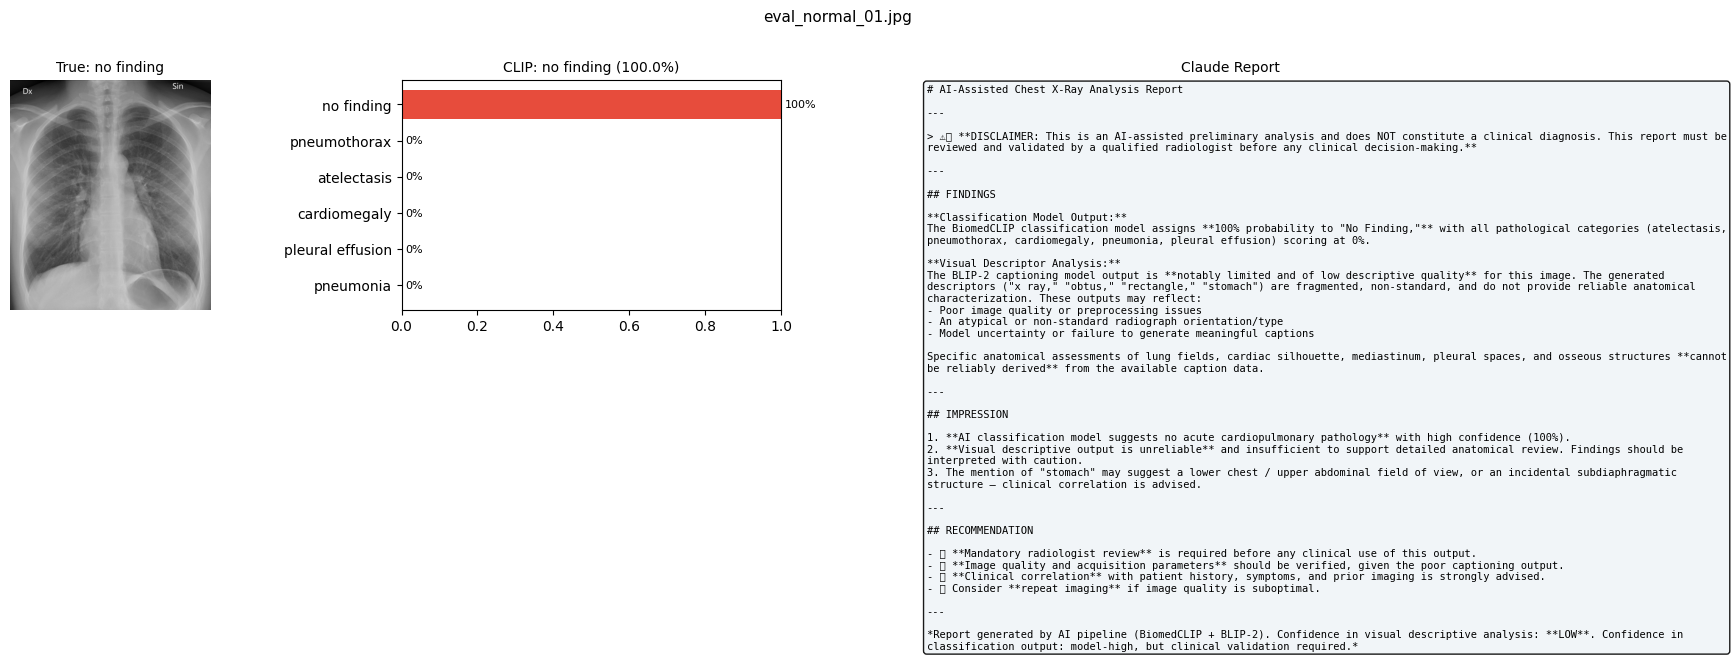

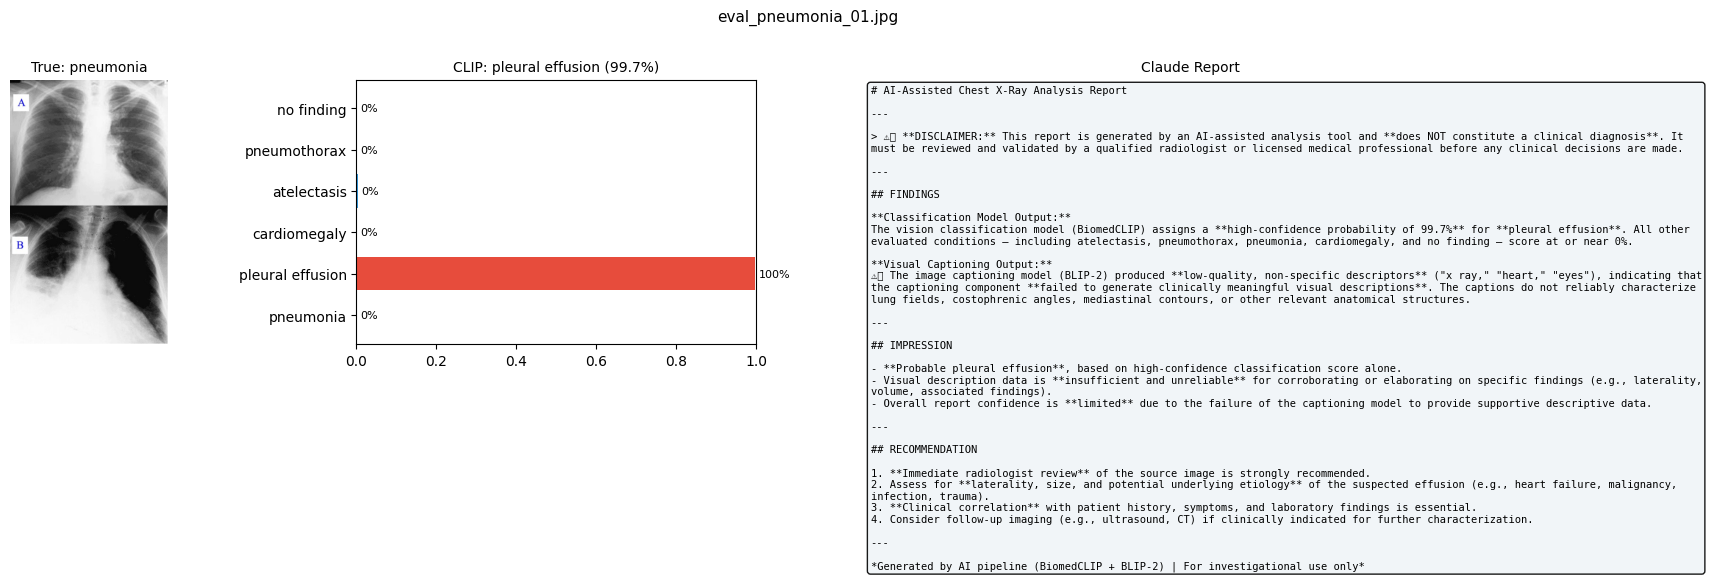

/var/folders/xl/h7p9qmt557vgrssq1g9w726r0000gn/T/ipykernel_40632/3148840776.py:32: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/nityasreecheera/chest-xray-analyzer/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


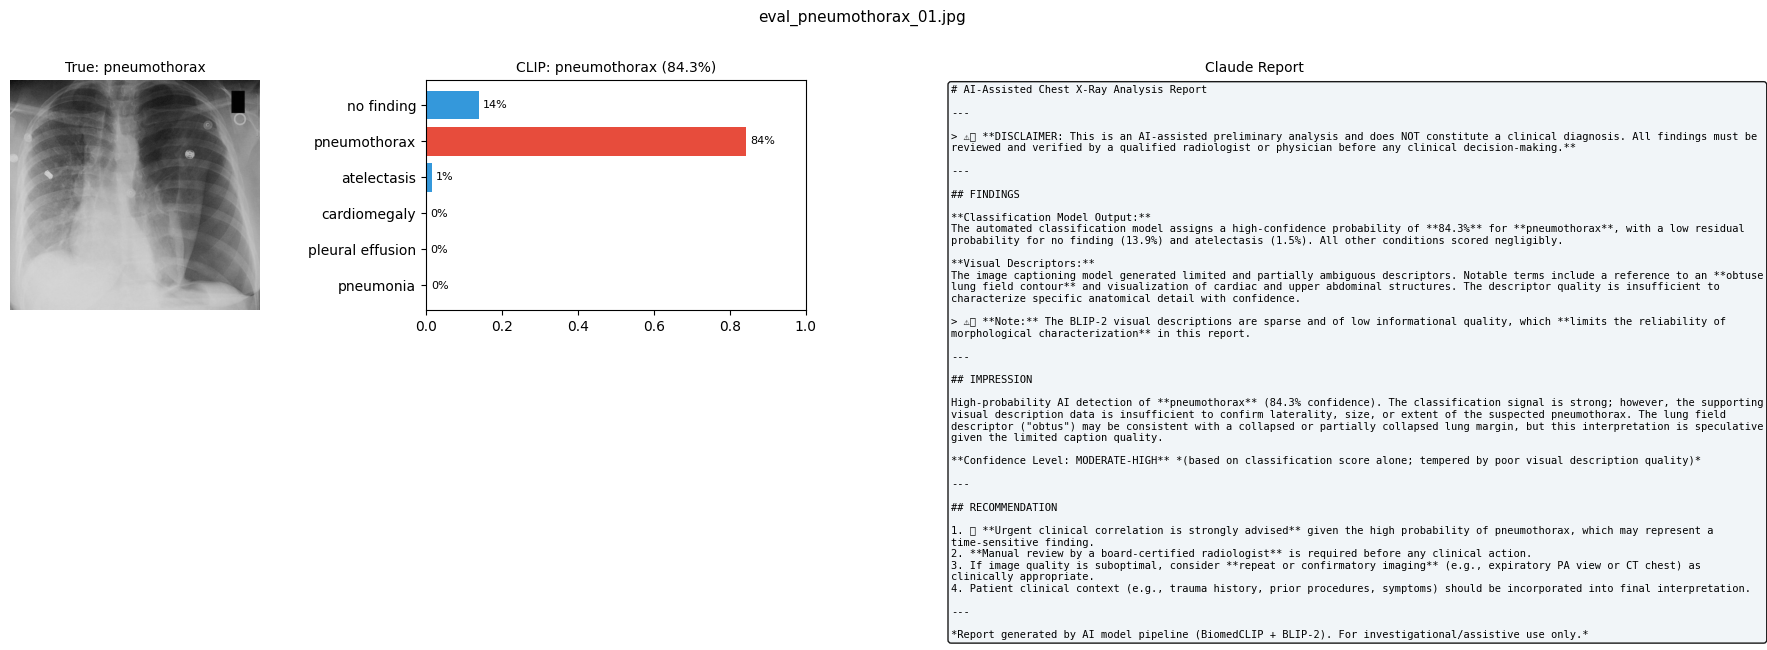

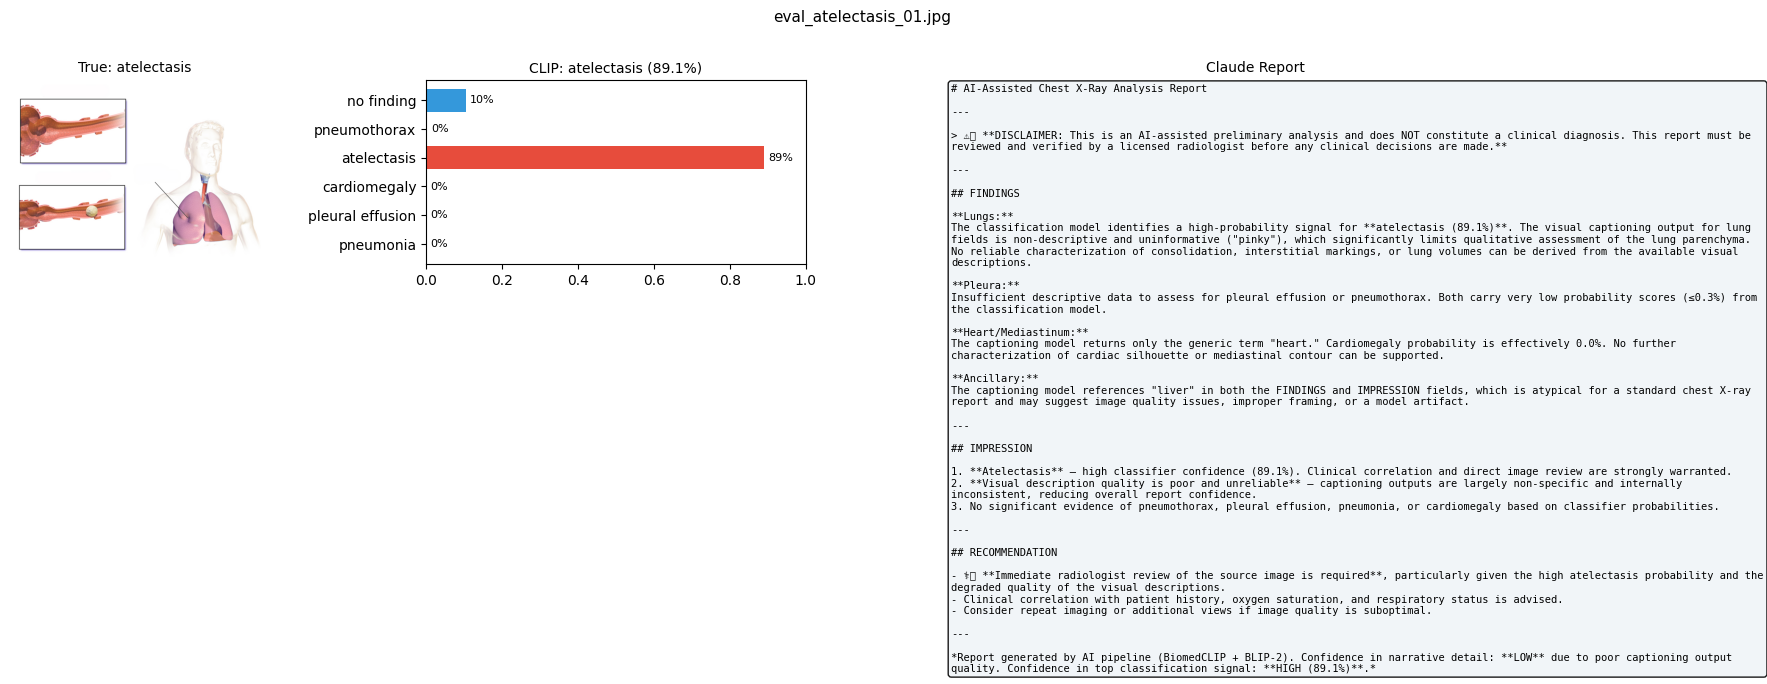

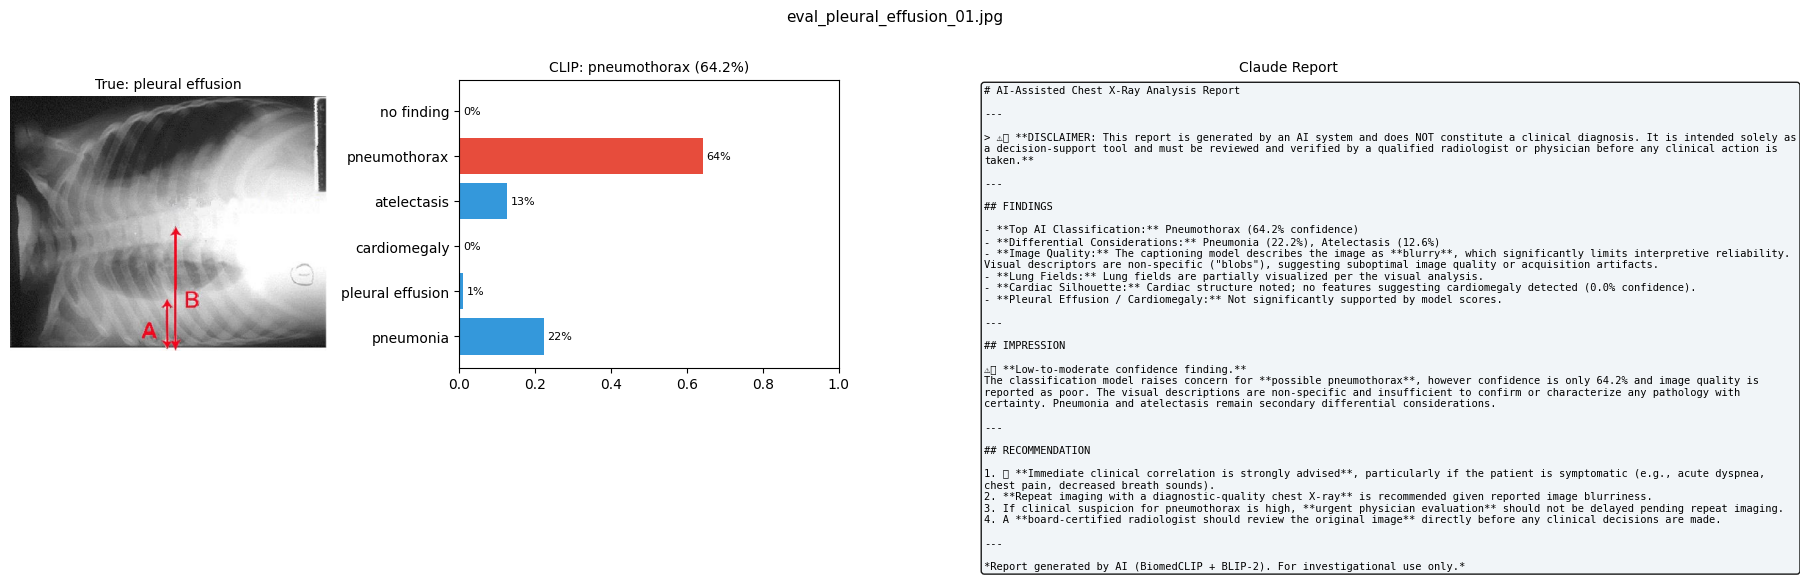

/var/folders/xl/h7p9qmt557vgrssq1g9w726r0000gn/T/ipykernel_40632/3148840776.py:32: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/nityasreecheera/chest-xray-analyzer/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


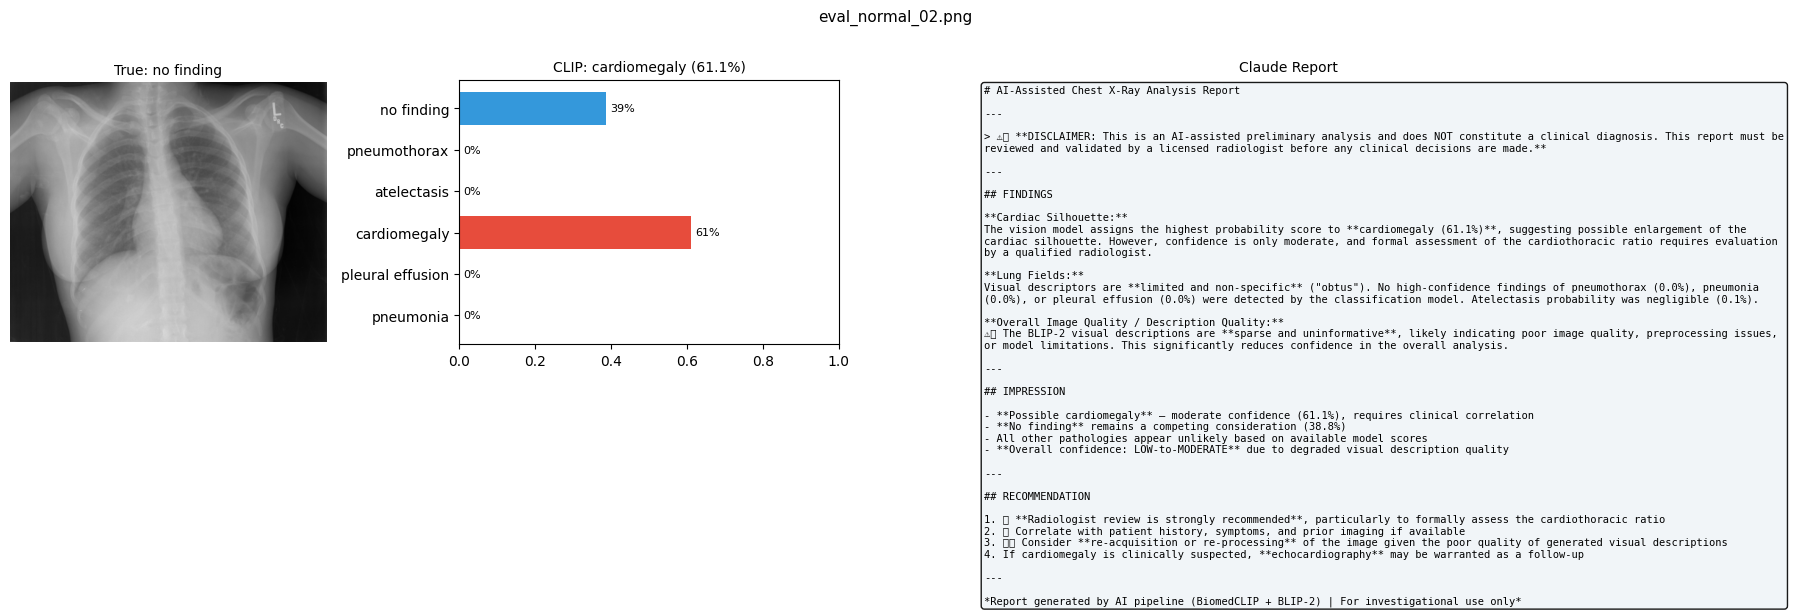

/var/folders/xl/h7p9qmt557vgrssq1g9w726r0000gn/T/ipykernel_40632/3148840776.py:32: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/nityasreecheera/chest-xray-analyzer/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


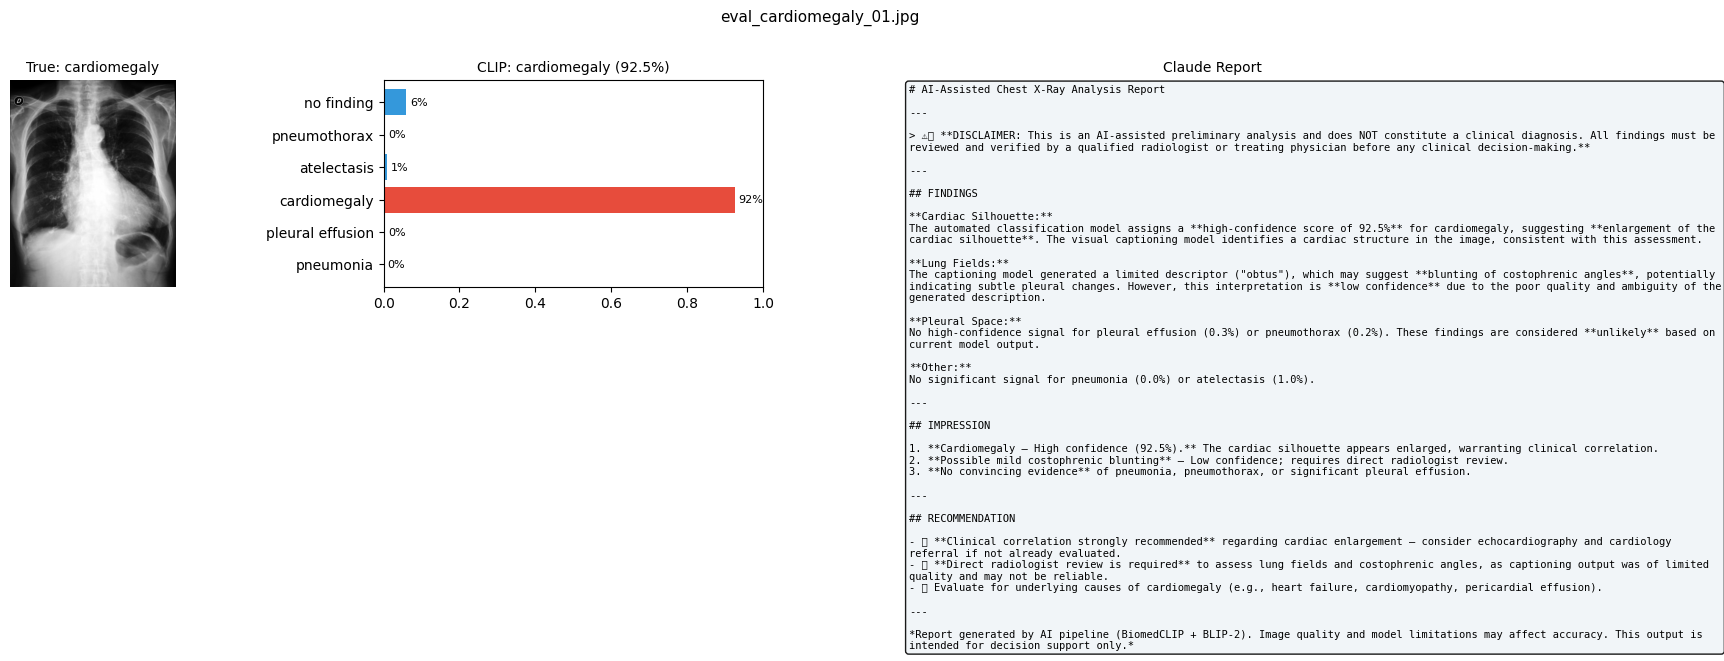

In [5]:
for r in all_results:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                             gridspec_kw={'width_ratios': [1, 1.2, 2]})

    # Column 1: X-ray image
    axes[0].imshow(r['image'], cmap='gray')
    axes[0].set_title(f"True: {r['true_label']}", fontsize=10)
    axes[0].axis('off')

    # Column 2: CLIP scores bar chart
    scores = r['clip']['scores']
    conditions = list(scores.keys())
    vals = [scores[c] for c in conditions]
    colors = ['#e74c3c' if c == r['clip']['top_condition'] else '#3498db' for c in conditions]
    bars = axes[1].barh(conditions, vals, color=colors)
    for bar, val in zip(bars, vals):
        axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.0%}', va='center', fontsize=8)
    axes[1].set_xlim(0, 1)
    axes[1].set_title(f"CLIP: {r['clip']['top_condition']} ({r['clip']['top_score']:.1%})", fontsize=10)

    # Column 3: Claude report
    report_text = r['report']
    axes[2].text(0.02, 0.98, report_text, transform=axes[2].transAxes,
                 fontsize=7.5, va='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.9),
                 wrap=True)
    axes[2].axis('off')
    axes[2].set_title('Claude Report', fontsize=10)

    plt.suptitle(r['filename'], fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()
    print()

## 4. Print all reports as plain text

In [6]:
for r in all_results:
    print(f"\n{'='*65}")
    print(f"FILE: {r['filename']}  |  True: {r['true_label']}  |  CLIP: {r['clip']['top_condition']} ({r['clip']['top_score']:.1%})")
    print('='*65)
    print(r['report'])


FILE: eval_normal_01.jpg  |  True: no finding  |  CLIP: no finding (100.0%)
# AI-Assisted Chest X-Ray Analysis Report

---

> ⚠️ **DISCLAIMER: This is an AI-assisted preliminary analysis and does NOT constitute a clinical diagnosis. This report must be reviewed and validated by a qualified radiologist before any clinical decision-making.**

---

## FINDINGS

**Classification Model Output:**
The BiomedCLIP classification model assigns **100% probability to "No Finding,"** with all pathological categories (atelectasis, pneumothorax, cardiomegaly, pneumonia, pleural effusion) scoring at 0%.

**Visual Descriptor Analysis:**
The BLIP-2 captioning model output is **notably limited and of low descriptive quality** for this image. The generated descriptors ("x ray," "obtus," "rectangle," "stomach") are fragmented, non-standard, and do not provide reliable anatomical characterization. These outputs may reflect:
- Poor image quality or preprocessing issues
- An atypical or non-standard radiogra